<a href="https://colab.research.google.com/github/overdosedbraincells/Healthcare_Data_Analysis/blob/main/Hasta_Memnuniyet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Eksik veri sayıları
Ad                   0
Bolum                0
Yas                  2
Tedavi_Suresi_Gun    0
Memnuniyet           1
dtype: int64
---------------------------------------------
En uzun tedavi süresi Nöroloji bölümünde ve 25.00 kadar.
Bu bölümün memnuniyet değerinin ortalaması 9.00


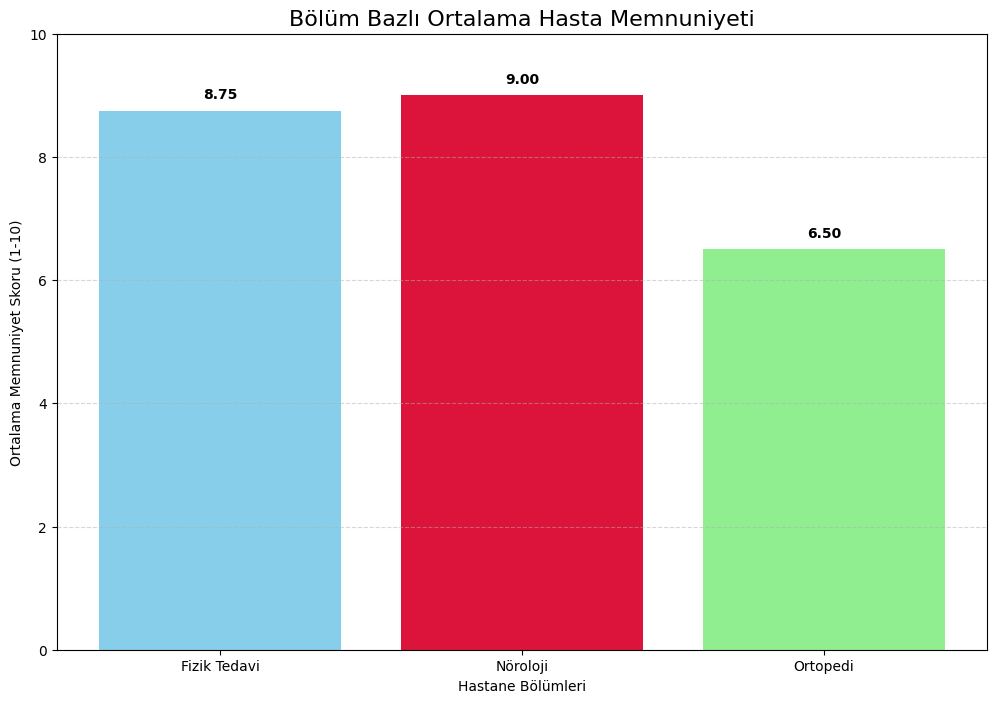

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


analiz_verisi = {
    'Ad': ['Ahmet', 'Ayşe', 'Mehmet', 'Fatma', 'Can', 'Selin', 'Zeynep', 'Ali'],
    'Bolum': ['Fizik Tedavi', 'Ortopedi', 'Fizik Tedavi', 'Nöroloji', 'Ortopedi', 'Fizik Tedavi', 'Nöroloji', 'Fizik Tedavi'],
    'Yas': [62, 34, np.nan, 45, 29, 58, np.nan, 70],
    'Tedavi_Suresi_Gun': [15, 10, 12, 20, 8, 14, 25, 18],
    'Memnuniyet': [9, 7, 8, np.nan, 6, 10, 9, 8]
}

df = pd.DataFrame(analiz_verisi)

print("Eksik veri sayıları")
print(df.isnull().sum())
print("-" * 45)

ortalama_yas = df["Yas"].mean()
df["Yas"] = df["Yas"].fillna(ortalama_yas)

df.dropna(subset=["Memnuniyet"], inplace=True)

gruplama= df.groupby("Bolum")["Tedavi_Suresi_Gun"].mean()

grup_max = gruplama.idxmax()
grup_max_sayi = gruplama.max()

memnuniyet = df.groupby("Bolum")["Memnuniyet"].mean()
grup_max_memnuniyet = memnuniyet[grup_max]


print(f"En uzun tedavi süresi {grup_max} bölümünde ve {grup_max_sayi:.2f} kadar.")
print(f"Bu bölümün memnuniyet değerinin ortalaması {grup_max_memnuniyet:.2f}")

plt.figure(figsize=(12, 8))
plt.bar(memnuniyet.index, memnuniyet.values, color=["skyblue", "crimson", "lightgreen"])
plt.title("Bölüm Bazlı Ortalama Hasta Memnuniyeti", fontsize=16)
plt.xlabel("Hastane Bölümleri", fontsize=10)
plt.ylabel("Ortalama Memnuniyet Skoru (1-10)", fontsize=10)
plt.ylim(0, 10)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(memnuniyet.values):
  plt.text(i, v + 0.2, f"{v:.2f}", ha="center", fontweight="bold")

plt.show()